# 03g — Percentile-Method Sensitivity v3 SAFE CHECKPOINT (**high priority**)

The current baseline computes Gringorten soil-moisture percentiles separately for each **calendar pentad** across 1995–2025. With 31 years, that means at most **31 reference values per grid/pentad**.

This notebook tests whether that relatively small seasonal reference sample materially affects the FD conclusions.

Three percentile constructions are compared:

- `EXACT`: current exact calendar pentad — maximum 31 reference samples;
- `WIN1`: target pentad ±1 pentad, circular — maximum 93 samples;
- `WIN2`: target pentad ±2 pentads, circular — maximum 155 samples.

For WIN1/WIN2, each target-pentad RZSM observation is ranked within the pooled neighboring-pentad seasonal reference population using the **same Gringorten formula**.

**Important:** WIN1/WIN2 are study-specific sensitivity experiments, not claimed as a new standard flash-drought percentile method.

The FD detector is held fixed at:
P40→P20, max onset 5, decline ≥5 pp/pentad, strict monotonic onset, persistence 3 pentads, recovery 1.

This notebook is intentionally **checkpointed one target pentad at a time**. If interrupted, rerun it; completed percentile-pentad files are reused.


**v2 fix:** removes residual scalar `pentad` coordinates before recreating the target-pentad dimension.

**v3 fix:** validates checkpoint NetCDF files with a real data read; corrupt or partial files are automatically rebuilt; writes are atomic via `.nc.partial`; assembly explicitly uses the same NetCDF backend.


In [1]:
from pathlib import Path
import json
import os
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da
import matplotlib.pyplot as plt
from scipy import stats

try:
    from dask.diagnostics import ProgressBar
except Exception:
    ProgressBar = None

warnings.filterwarnings("once")

RZSM_DIR = Path(
    r"D:\ERA5_LAND\output_rzsm"
)

RZSM_FILE = (
    RZSM_DIR
    / "rzsm_pentad_1995_2025.nc"
)

EXACT_PERCENTILE_FILE = (
    RZSM_DIR
    / "rzsm_percentile_gringorten_1995_2025.nc"
)

BASELINE_FILE = Path(
    r"D:\ERA5_LAND\output_fd_03b_sensitivity\fd_detection_M2A_1995_2025_indonesia.nc"
)

OUTPUT_DIR = Path(
    r"D:\ERA5_LAND\output_fd_03g_percentile_sensitivity"
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CHECKPOINT_DIR = (
    OUTPUT_DIR
    / "_percentile_checkpoints"
)
CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

WINDOWS_TO_BUILD = [1, 2]

FORCE_REBUILD_PERCENTILES = False
FORCE_RERUN_DETECTION = False

START_THRESHOLD = 40.0
DROUGHT_THRESHOLD = 20.0
MIN_DECLINE_RATE = 5.0
MIN_TOTAL_DURATION = 4
STRICT_MONOTONIC = True

ANALYSIS_START = 1996
ANALYSIS_END = 2024

LAT_CHUNK = 15
LON_CHUNK = 40
TIME_CHUNK_OUTPUT = 73
FIG_DPI = 300

try:
    import h5netcdf  # noqa
    NETCDF_ENGINE = "h5netcdf"
except Exception:
    NETCDF_ENGINE = "netcdf4"

for path in [
    RZSM_FILE,
    EXACT_PERCENTILE_FILE,
    BASELINE_FILE,
]:
    if not path.exists():
        raise FileNotFoundError(path)

print(
    "NetCDF engine:",
    NETCDF_ENGINE,
)
print(
    "Checkpoint directory:",
    CHECKPOINT_DIR,
)


NetCDF engine: h5netcdf
Checkpoint directory: D:\ERA5_LAND\output_fd_03g_percentile_sensitivity\_percentile_checkpoints


In [2]:
from numba import njit

@njit
def detect_one_series_robustness(
    p,
    start_threshold,
    drought_threshold,
    min_decline_rate,
    min_total_duration,
    strict_monotonic,
    max_onset_pentads,
    min_below_p20_pentads,
    recovery_consecutive_pentads,
):
    # Reduced-output reproduction of the 03b event engine.
    n = p.size

    event_start = np.zeros(n, dtype=np.int8)
    drought_core = np.zeros(n, dtype=np.int8)

    duration = np.full(n, -1, dtype=np.int16)
    onset_time = np.full(n, -1, dtype=np.int16)
    below_p20_duration = np.full(n, -1, dtype=np.int16)

    onset_speed = np.full(n, np.nan, dtype=np.float32)
    severity40 = np.full(n, np.nan, dtype=np.float32)
    minimum_percentile = np.full(n, np.nan, dtype=np.float32)

    i = 0

    while i < n - 1:
        if np.isnan(p[i]) or np.isnan(p[i + 1]):
            i += 1
            continue

        # Same baseline logic used by 03b.
        if not (
            p[i] >= start_threshold
            and p[i + 1] < start_threshold
        ):
            i += 1
            continue

        baseline = i
        crossing = -1
        j = baseline + 1

        while j < n:
            if np.isnan(p[j]) or np.isnan(p[j - 1]):
                break

            if (
                max_onset_pentads > 0
                and (j - baseline) > max_onset_pentads
            ):
                break

            if strict_monotonic and not (p[j] < p[j - 1]):
                break

            if p[j] < drought_threshold:
                crossing = j
                break

            j += 1

        if crossing < 0:
            i += 1
            continue

        current_onset_time = crossing - baseline
        current_onset_speed = (
            p[baseline] - p[crossing]
        ) / current_onset_time

        if current_onset_speed < min_decline_rate:
            i += 1
            continue

        # Same recovery logic as 03b.
        termination = -1
        missing_during_event = False
        above_run = 0
        above_run_start = -1
        k = crossing + 1

        while k < n:
            if np.isnan(p[k]):
                missing_during_event = True
                break

            if p[k] >= drought_threshold:
                if above_run == 0:
                    above_run_start = k

                above_run += 1

                if above_run >= recovery_consecutive_pentads:
                    termination = above_run_start
                    break
            else:
                above_run = 0
                above_run_start = -1

            k += 1

        if missing_during_event:
            i = k + 1
            continue

        # Right-censored event.
        if termination < 0:
            break

        total_duration = termination - baseline

        initial_below_p20_run = 0
        q = crossing
        while (
            q < termination
            and p[q] < drought_threshold
        ):
            initial_below_p20_run += 1
            q += 1

        if total_duration < min_total_duration:
            i = termination
            continue

        if (
            initial_below_p20_run
            < min_below_p20_pentads
        ):
            i = termination
            continue

        min_value = p[crossing]
        sev40 = 0.0

        for q in range(baseline + 1, termination):
            if p[q] < min_value:
                min_value = p[q]

            if p[q] < start_threshold:
                sev40 += start_threshold - p[q]

        event_start[baseline] = 1
        duration[baseline] = total_duration
        onset_time[baseline] = current_onset_time
        below_p20_duration[baseline] = initial_below_p20_run
        onset_speed[baseline] = current_onset_speed
        severity40[baseline] = sev40
        minimum_percentile[baseline] = min_value

        for q in range(crossing, termination):
            if p[q] < drought_threshold:
                drought_core[q] = 1

        i = termination

    return (
        event_start,
        drought_core,
        duration,
        onset_time,
        below_p20_duration,
        onset_speed,
        severity40,
        minimum_percentile,
    )


@njit
def detect_block_robustness(
    p_block,
    start_threshold,
    drought_threshold,
    min_decline_rate,
    min_total_duration,
    strict_monotonic,
    max_onset_pentads,
    min_below_p20_pentads,
    recovery_consecutive_pentads,
):
    original_shape = p_block.shape
    nt = original_shape[-1]
    npixel = p_block.size // nt
    flat = p_block.reshape((npixel, nt))

    event_start = np.zeros((npixel, nt), dtype=np.int8)
    drought_core = np.zeros((npixel, nt), dtype=np.int8)

    duration = np.full((npixel, nt), -1, dtype=np.int16)
    onset_time = np.full((npixel, nt), -1, dtype=np.int16)
    below_p20_duration = np.full((npixel, nt), -1, dtype=np.int16)

    onset_speed = np.full((npixel, nt), np.nan, dtype=np.float32)
    severity40 = np.full((npixel, nt), np.nan, dtype=np.float32)
    minimum_percentile = np.full((npixel, nt), np.nan, dtype=np.float32)

    for pixel in range(npixel):
        r = detect_one_series_robustness(
            flat[pixel],
            start_threshold,
            drought_threshold,
            min_decline_rate,
            min_total_duration,
            strict_monotonic,
            max_onset_pentads,
            min_below_p20_pentads,
            recovery_consecutive_pentads,
        )

        event_start[pixel] = r[0]
        drought_core[pixel] = r[1]
        duration[pixel] = r[2]
        onset_time[pixel] = r[3]
        below_p20_duration[pixel] = r[4]
        onset_speed[pixel] = r[5]
        severity40[pixel] = r[6]
        minimum_percentile[pixel] = r[7]

    return (
        event_start.reshape(original_shape),
        drought_core.reshape(original_shape),
        duration.reshape(original_shape),
        onset_time.reshape(original_shape),
        below_p20_duration.reshape(original_shape),
        onset_speed.reshape(original_shape),
        severity40.reshape(original_shape),
        minimum_percentile.reshape(original_shape),
    )


OUTPUT_NAMES = [
    "fd_event_start",
    "fd_drought_core",
    "duration_pentads_at_start",
    "onset_time_pentads_at_start",
    "below_p20_pentads_at_start",
    "onset_speed_at_start",
    "severity_p40_at_start",
    "minimum_percentile_at_start",
]

OUTPUT_DTYPES = [
    np.int8,
    np.int8,
    np.int16,
    np.int16,
    np.int16,
    np.float32,
    np.float32,
    np.float32,
]


def percentile_to_time_index(pct):
    required = {
        "year",
        "pentad",
        "latitude",
        "longitude",
    }
    if not required.issubset(pct.dims):
        raise ValueError(
            f"Percentile dims must contain {required}; "
            f"found {pct.dims}"
        )

    pct = pct.transpose(
        "year",
        "pentad",
        "latitude",
        "longitude",
    )

    years = np.asarray(
        pct["year"].values,
        dtype=np.int16,
    )
    pentads = np.asarray(
        pct["pentad"].values,
        dtype=np.int16,
    )

    stacked = (
        pct.stack(time_index=("year", "pentad"))
        .transpose(
            "latitude",
            "longitude",
            "time_index",
        )
        .reset_index(
            "time_index",
            drop=True,
        )
    )

    year_step = np.repeat(
        years,
        len(pentads),
    ).astype(np.int16)

    pentad_step = np.tile(
        pentads,
        len(years),
    ).astype(np.int16)

    stacked = stacked.assign_coords(
        time_index=(
            "time_index",
            np.arange(
                stacked.sizes["time_index"],
                dtype=np.int32,
            ),
        ),
        year=("time_index", year_step),
        pentad=("time_index", pentad_step),
    )

    return stacked.chunk({
        "latitude": LAT_CHUNK,
        "longitude": LON_CHUNK,
        "time_index": -1,
    })


def build_detection(
    pct_time,
    valid,
    label,
    max_onset,
    persistence,
    recovery=1,
):
    result = xr.apply_ufunc(
        detect_block_robustness,
        pct_time,
        input_core_dims=[["time_index"]],
        output_core_dims=[
            ["time_index"]
            for _ in OUTPUT_NAMES
        ],
        vectorize=False,
        dask="parallelized",
        output_dtypes=OUTPUT_DTYPES,
        kwargs={
            "start_threshold": START_THRESHOLD,
            "drought_threshold": DROUGHT_THRESHOLD,
            "min_decline_rate": MIN_DECLINE_RATE,
            "min_total_duration": MIN_TOTAL_DURATION,
            "strict_monotonic": STRICT_MONOTONIC,
            "max_onset_pentads": int(max_onset),
            "min_below_p20_pentads": int(persistence),
            "recovery_consecutive_pentads": int(recovery),
        },
        dask_gufunc_kwargs={
            "allow_rechunk": False,
        },
    )

    data_vars = {}

    for arr, name, dtype in zip(
        result,
        OUTPUT_NAMES,
        OUTPUT_DTYPES,
    ):
        arr = arr.rename(name).transpose(
            "time_index",
            "latitude",
            "longitude",
        )

        if name in [
            "fd_event_start",
            "fd_drought_core",
        ]:
            arr = arr.where(
                valid,
                other=0,
            ).astype(dtype)
        elif np.issubdtype(
            np.dtype(dtype),
            np.integer,
        ):
            arr = arr.where(
                valid,
                other=-1,
            ).astype(dtype)
        else:
            arr = arr.where(valid).astype(dtype)

        data_vars[name] = arr

    out = xr.Dataset(data_vars)
    out["valid_grid_mask"] = valid.astype(np.int8)

    out.attrs.update({
        "variant": label,
        "start_threshold_percentile": START_THRESHOLD,
        "drought_threshold_percentile": DROUGHT_THRESHOLD,
        "minimum_mean_decline_rate_pp_per_pentad": MIN_DECLINE_RATE,
        "minimum_total_duration_pentad_intervals": MIN_TOTAL_DURATION,
        "strict_monotonic_onset": str(STRICT_MONOTONIC),
        "maximum_onset_pentads": int(max_onset),
        "minimum_initial_consecutive_below_p20_pentads": int(persistence),
        "recovery_consecutive_pentads": int(recovery),
        "right_censored_events": "excluded",
        "purpose": "definition sensitivity / robustness",
    })

    return out


def detection_encoding(ds):
    enc = {}

    for name, var in ds.data_vars.items():
        cfg = {
            "zlib": True,
            "complevel": 4,
            "shuffle": True,
        }

        if var.dims == (
            "time_index",
            "latitude",
            "longitude",
        ):
            cfg["chunksizes"] = (
                TIME_CHUNK_OUTPUT,
                min(
                    LAT_CHUNK,
                    var.sizes["latitude"],
                ),
                min(
                    LON_CHUNK,
                    var.sizes["longitude"],
                ),
            )
        elif var.dims == (
            "latitude",
            "longitude",
        ):
            cfg["chunksizes"] = (
                min(
                    LAT_CHUNK,
                    var.sizes["latitude"],
                ),
                min(
                    LON_CHUNK,
                    var.sizes["longitude"],
                ),
            )

        if np.issubdtype(
            var.dtype,
            np.floating,
        ):
            cfg["_FillValue"] = np.float32(np.nan)
        else:
            cfg["_FillValue"] = None

        enc[name] = cfg

    return enc


def write_detection(
    pct_time,
    valid,
    output_file,
    label,
    max_onset,
    persistence,
    recovery=1,
    force=False,
):
    if output_file.exists() and not force:
        print("Using existing:", output_file)
        return output_file

    if output_file.exists():
        output_file.unlink()

    lazy = build_detection(
        pct_time=pct_time,
        valid=valid,
        label=label,
        max_onset=max_onset,
        persistence=persistence,
        recovery=recovery,
    )

    for name in lazy.variables:
        lazy[name].encoding = {}

    print("Writing:", output_file)

    if ProgressBar is not None:
        with ProgressBar():
            lazy.to_netcdf(
                output_file,
                engine=NETCDF_ENGINE,
                encoding=detection_encoding(lazy),
            )
    else:
        lazy.to_netcdf(
            output_file,
            engine=NETCDF_ENGINE,
            encoding=detection_encoding(lazy),
        )

    print("Saved:", output_file)
    return output_file


In [3]:
def subset_analysis(ds):
    y = np.asarray(
        ds["year"].values,
        dtype=int,
    )
    idx = np.flatnonzero(
        (y >= ANALYSIS_START)
        & (y <= ANALYSIS_END)
    )
    if idx.size == 0:
        raise ValueError("No analysis years found.")
    return ds.isel(time_index=idx)


def cosine_weights(valid):
    wlat = xr.DataArray(
        np.cos(
            np.deg2rad(
                valid["latitude"].values
            )
        ),
        coords={
            "latitude": valid["latitude"]
        },
        dims=("latitude",),
    )
    return (
        wlat
        * xr.ones_like(
            valid,
            dtype=np.float32,
        )
    ).where(valid)


def jaccard(a, b):
    calc = xr.Dataset({
        "intersection": (a & b).sum(),
        "union": (a | b).sum(),
    }).compute()

    union = float(calc["union"])
    if union == 0:
        return np.nan

    return float(calc["intersection"]) / union


def summarize_detection(ds, valid, name):
    d = subset_analysis(ds)

    start = (
        d["fd_event_start"] == 1
    ).where(valid, False)

    core = (
        d["fd_drought_core"] == 1
    ).where(valid, False)

    weights = cosine_weights(valid)
    denominator = weights.sum()

    n_years = (
        ANALYSIS_END
        - ANALYSIS_START
        + 1
    )

    start_count = int(
        start.sum().compute()
    )
    affected_grid = int(
        start.any("time_index")
        .sum()
        .compute()
    )

    freq_count = (
        start.sum("time_index")
        .compute()
        .where(valid)
    )

    onset_area = (
        (
            start.astype(np.float32)
            * weights
        )
        .sum(("latitude", "longitude"))
        / denominator
        * 100.0
    )

    core_area = (
        (
            core.astype(np.float32)
            * weights
        )
        .sum(("latitude", "longitude"))
        / denominator
        * 100.0
    )

    area = xr.Dataset({
        "onset": onset_area,
        "core": core_area,
    }).compute()

    years = np.asarray(
        d["year"].values,
        dtype=int,
    )

    annual_rows = []

    for yr in range(
        ANALYSIS_START,
        ANALYSIS_END + 1,
    ):
        mask = years == yr

        annual_rows.append({
            "method": name,
            "year": int(yr),
            "annual_onset_exposure_area_percent_pentad": float(
                np.nansum(
                    area["onset"].values[mask]
                )
            ),
            "maximum_new_onset_area_percent": float(
                np.nanmax(
                    area["onset"].values[mask]
                )
            ),
            "maximum_drought_core_area_percent": float(
                np.nanmax(
                    area["core"].values[mask]
                )
            ),
        })

    characteristic_rows = []

    for var in [
        "onset_speed_at_start",
        "onset_time_pentads_at_start",
        "duration_pentads_at_start",
        "below_p20_pentads_at_start",
        "severity_p40_at_start",
        "minimum_percentile_at_start",
    ]:
        vals = (
            d[var]
            .where(start)
            .stack(
                sample=(
                    "time_index",
                    "latitude",
                    "longitude",
                )
            )
            .dropna("sample")
            .compute()
            .values
        )

        characteristic_rows.append({
            "method": name,
            "variable": var,
            "n": int(vals.size),
            "mean": (
                float(np.mean(vals))
                if vals.size
                else np.nan
            ),
            "median": (
                float(np.median(vals))
                if vals.size
                else np.nan
            ),
            "q25": (
                float(np.quantile(vals, 0.25))
                if vals.size
                else np.nan
            ),
            "q75": (
                float(np.quantile(vals, 0.75))
                if vals.size
                else np.nan
            ),
        })

    summary = {
        "method": name,
        "gridcell_event_starts_1996_2024": start_count,
        "affected_grid_count": affected_grid,
        "affected_grid_percent": (
            100.0
            * affected_grid
            / int(valid.sum().item())
        ),
        "mean_events_per_decade_valid_grid": float(
            (
                freq_count
                / n_years
                * 10.0
            )
            .where(valid)
            .mean()
        ),
        "maximum_events_per_decade": float(
            (
                freq_count
                / n_years
                * 10.0
            )
            .where(valid)
            .max()
        ),
    }

    return (
        summary,
        pd.DataFrame(annual_rows),
        pd.DataFrame(characteristic_rows),
        freq_count,
    )


def compare_variant(
    baseline,
    variant,
    valid,
    baseline_name,
    variant_name,
):
    b = subset_analysis(baseline)
    v = subset_analysis(variant)

    bstart = (
        b["fd_event_start"] == 1
    ).where(valid, False)

    vstart = (
        v["fd_event_start"] == 1
    ).where(valid, False)

    bcore = (
        b["fd_drought_core"] == 1
    ).where(valid, False)

    vcore = (
        v["fd_drought_core"] == 1
    ).where(valid, False)

    start_j = jaccard(bstart, vstart)
    core_j = jaccard(bcore, vcore)

    bf = (
        bstart.sum("time_index")
        .compute()
        .where(valid)
    )
    vf = (
        vstart.sum("time_index")
        .compute()
        .where(valid)
    )

    x = bf.values[valid.values]
    y = vf.values[valid.values]

    ok = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    if ok.sum() > 2:
        sr, sp = stats.spearmanr(
            x[ok],
            y[ok],
        )
        pr, pp = stats.pearsonr(
            x[ok],
            y[ok],
        )
    else:
        sr = sp = pr = pp = np.nan

    bq90 = np.nanquantile(
        x[ok],
        0.90,
    )
    vq90 = np.nanquantile(
        y[ok],
        0.90,
    )

    bhot = (
        bf >= bq90
    ).where(valid, False)

    vhot = (
        vf >= vq90
    ).where(valid, False)

    return {
        "baseline": baseline_name,
        "variant": variant_name,
        "event_start_jaccard": start_j,
        "drought_core_jaccard": core_j,
        "frequency_spearman_r": float(sr),
        "frequency_spearman_p": float(sp),
        "frequency_pearson_r": float(pr),
        "frequency_pearson_p": float(pp),
        "q90_hotspot_jaccard": jaccard(
            bhot,
            vhot,
        ),
    }


## 1. Load RZSM, exact percentile, and Indonesia mask


In [4]:
baseline = xr.open_dataset(
    BASELINE_FILE,
    chunks={
        "time_index": 73,
        "latitude": LAT_CHUNK,
        "longitude": LON_CHUNK,
    },
    mask_and_scale=False,
)

valid = (
    baseline["valid_grid_mask"] == 1
).compute()

rzsm_ds = xr.open_dataset(
    RZSM_FILE,
    chunks={
        "year": -1,
        "pentad": -1,
        "latitude": LAT_CHUNK,
        "longitude": LON_CHUNK,
    },
)

exact_ds = xr.open_dataset(
    EXACT_PERCENTILE_FILE,
    chunks={
        "year": -1,
        "pentad": -1,
        "latitude": LAT_CHUNK,
        "longitude": LON_CHUNK,
    },
)

rzsm = (
    rzsm_ds["rzsm"]
    .transpose(
        "year",
        "pentad",
        "latitude",
        "longitude",
    )
)

exact_pct = (
    exact_ds["rzsm_percentile"]
    .transpose(
        "year",
        "pentad",
        "latitude",
        "longitude",
    )
    .where(valid)
)

for da0, label in [
    (rzsm, "RZSM"),
    (exact_pct, "exact percentile"),
]:
    if not np.array_equal(
        da0["latitude"].values,
        valid["latitude"].values,
    ):
        raise ValueError(
            f"Latitude mismatch: {label}"
        )

    if not np.array_equal(
        da0["longitude"].values,
        valid["longitude"].values,
    ):
        raise ValueError(
            f"Longitude mismatch: {label}"
        )

years = np.asarray(
    rzsm["year"].values,
    dtype=int,
)
pentads = np.asarray(
    rzsm["pentad"].values,
    dtype=int,
)

if not np.array_equal(
    pentads,
    np.arange(1, 74),
):
    raise ValueError(
        "Expected pentad coordinate 1..73."
    )

print("RZSM shape:", rzsm.shape)
print("Years:", years[0], "-", years[-1])
print(
    "Valid Indonesia grids:",
    int(valid.sum().item()),
)


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


RZSM shape: (31, 73, 171, 461)
Years: 1995 - 2025
Valid Indonesia grids: 14857


C:\Users\User\AppData\Local\Temp\ipykernel_16600\3979882998.py:15: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 15. This could degrade performance. Instead, consider rechunking after loading.
  rzsm_ds = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_16600\3979882998.py:15: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 40. This could degrade performance. Instead, consider rechunking after loading.
  rzsm_ds = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_16600\3979882998.py:25: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 15. This could degrade performance. Instead, consider rechunking after loading.
  exact_ds = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_16600\3979882998.py:25: UserWarning: The specified chunks separate the stored chunks along dimension "longitu

## 2. Build WIN1/WIN2 Gringorten percentiles

The seasonal window wraps around year boundaries. For example, target pentad 1 with WIN1 uses reference pentads 73, 1, and 2.

The target observation itself remains part of its reference sample, matching the self-inclusion behavior of the current exact-pentad empirical percentile.


In [5]:
def wrapped_pentads(target, half_window, n_pentads=73):
    return [((int(target)-1+offset) % n_pentads)+1
            for offset in range(-half_window, half_window+1)]


def checkpoint_path(half_window, target_pentad):
    folder = CHECKPOINT_DIR / f"window_pm{half_window}"
    folder.mkdir(parents=True, exist_ok=True)
    return folder / f"pct_pentad_{int(target_pentad):02d}.nc"


def final_window_path(half_window):
    return OUTPUT_DIR / f"rzsm_percentile_gringorten_window_pm{half_window}_1995_2025.nc"


def validate_checkpoint(path, expected_pentad=None):
    path = Path(path)
    if not path.exists():
        return False
    try:
        with xr.open_dataset(path, engine=NETCDF_ENGINE) as test:
            if not {"rzsm_percentile", "n_reference_samples"}.issubset(test.data_vars):
                return False
            if test.sizes.get("pentad") != 1:
                return False
            if test.sizes.get("year") != len(years):
                return False
            if test.sizes.get("latitude") != valid.sizes["latitude"]:
                return False
            if test.sizes.get("longitude") != valid.sizes["longitude"]:
                return False
            if expected_pentad is not None:
                found = int(np.asarray(test["pentad"].values).ravel()[0])
                if found != int(expected_pentad):
                    return False
            # force a real HDF data read
            _ = test["rzsm_percentile"].isel(year=0, pentad=0, latitude=0, longitude=0).load().item()
        return True
    except Exception:
        return False


def remove_corrupt(path, expected_pentad=None):
    path = Path(path)
    if path.exists() and not validate_checkpoint(path, expected_pentad):
        print("CORRUPT/INCOMPLETE -> delete and rebuild:", path.name)
        try:
            path.unlink()
        except FileNotFoundError:
            pass
    partial = path.with_suffix(path.suffix + ".partial")
    if partial.exists():
        try:
            partial.unlink()
        except FileNotFoundError:
            pass


def build_target_percentile(target_pentad, half_window):
    out = checkpoint_path(half_window, target_pentad)

    if out.exists() and not FORCE_REBUILD_PERCENTILES:
        if validate_checkpoint(out, target_pentad):
            print(f"WIN{half_window} pentad {target_pentad:02d}: valid checkpoint -> reuse")
            return out
        remove_corrupt(out, target_pentad)

    if out.exists():
        out.unlink()
    partial = out.with_suffix(out.suffix + ".partial")
    if partial.exists():
        partial.unlink()

    neighbors = wrapped_pentads(target_pentad, half_window, len(pentads))
    pieces=[]
    for q in neighbors:
        pieces.append(
            rzsm.sel(pentad=int(q), drop=True)
                .expand_dims(reference_pentad=[int(q)])
        )

    pool = xr.concat(pieces, dim="reference_pentad").where(valid)
    stacked = (pool.stack(sample=("reference_pentad","year"))
                    .transpose("sample","latitude","longitude")
                    .chunk({"sample":-1,"latitude":LAT_CHUNK,"longitude":LON_CHUNK}))
    ranked = stacked.rank("sample")
    nref = stacked.notnull().sum("sample")
    target_rank = (ranked.unstack("sample")
                         .sel(reference_pentad=int(target_pentad), drop=True)
                         .transpose("year","latitude","longitude"))
    for coord_name in ["pentad","reference_pentad"]:
        if coord_name in target_rank.coords and coord_name not in target_rank.dims:
            target_rank = target_rank.drop_vars(coord_name)

    pct = (100.0*(target_rank-0.44)/(nref+0.12)).where(valid)
    if "pentad" in pct.coords and "pentad" not in pct.dims:
        pct = pct.drop_vars("pentad")
    pct = (pct.expand_dims(pentad=[int(target_pentad)])
              .transpose("year","pentad","latitude","longitude")
              .astype(np.float32)
              .rename("rzsm_percentile"))
    nref_out = (nref.expand_dims(pentad=[int(target_pentad)])
                    .transpose("pentad","latitude","longitude")
                    .astype(np.int16)
                    .rename("n_reference_samples"))
    ds_out=xr.Dataset({"rzsm_percentile":pct,"n_reference_samples":nref_out})
    ds_out.attrs.update({
        "window_half_width_pentads":int(half_window),
        "maximum_reference_samples":int(len(years)*(2*half_window+1)),
        "purpose":"percentile-construction sensitivity / robustness",
    })
    print(f"WIN{half_window} pentad {target_pentad:02d}: building {neighbors}")

    # atomic write: partial -> validate -> final
    try:
        if ProgressBar is not None:
            with ProgressBar():
                ds_out.to_netcdf(partial, engine=NETCDF_ENGINE)
        else:
            ds_out.to_netcdf(partial, engine=NETCDF_ENGINE)
        with xr.open_dataset(partial, engine=NETCDF_ENGINE) as chk:
            _ = chk["rzsm_percentile"].isel(year=0,pentad=0,latitude=0,longitude=0).load().item()
        os.replace(partial, out)
    except Exception:
        if partial.exists():
            try: partial.unlink()
            except Exception: pass
        raise

    if not validate_checkpoint(out, target_pentad):
        if out.exists(): out.unlink()
        raise OSError(f"Post-write validation failed: {out}")
    print(f"WIN{half_window} pentad {target_pentad:02d}: checkpoint OK")
    return out


def validate_final_window(path):
    path=Path(path)
    if not path.exists(): return False
    try:
        with xr.open_dataset(path, engine=NETCDF_ENGINE) as ds_check:
            if "rzsm_percentile" not in ds_check: return False
            if ds_check.sizes.get("pentad") != len(pentads): return False
            if ds_check.sizes.get("year") != len(years): return False
            if not np.array_equal(np.asarray(ds_check["pentad"].values,dtype=int), pentads): return False
            _ = ds_check["rzsm_percentile"].isel(year=0,pentad=0,latitude=0,longitude=0).load().item()
        return True
    except Exception:
        return False


def assemble_window(half_window):
    final=final_window_path(half_window)
    if final.exists() and not FORCE_REBUILD_PERCENTILES and validate_final_window(final):
        print("Using existing valid final:", final)
        return final
    if final.exists():
        print("Removing invalid final:", final)
        final.unlink()

    # validate/rebuild each checkpoint before multi-file assembly
    files=[]
    for p in pentads:
        p=int(p)
        cp=checkpoint_path(half_window,p)
        if not validate_checkpoint(cp,p):
            remove_corrupt(cp,p)
            cp=build_target_percentile(p,half_window)
        else:
            print(f"WIN{half_window} pentad {p:02d}: valid checkpoint -> reuse")
        files.append(cp)

    print(f"WIN{half_window}: all {len(files)} checkpoints validated")
    partial=final.with_suffix(final.suffix+".partial")
    if partial.exists(): partial.unlink()

    combined=xr.open_mfdataset(
        files,
        engine=NETCDF_ENGINE,
        combine="nested",
        concat_dim="pentad",
        data_vars="minimal",
        coords="minimal",
        compat="override",
        parallel=False,
        chunks={"year":-1,"pentad":1,"latitude":LAT_CHUNK,"longitude":LON_CHUNK},
    ).sortby("pentad")
    try:
        print(f"WIN{half_window}: assembling final percentile file...")
        if ProgressBar is not None:
            with ProgressBar():
                combined.to_netcdf(partial, engine=NETCDF_ENGINE)
        else:
            combined.to_netcdf(partial, engine=NETCDF_ENGINE)
    finally:
        combined.close()

    if not validate_final_window(partial):
        if partial.exists(): partial.unlink()
        raise OSError(f"Assembled file failed validation: {partial}")
    os.replace(partial,final)
    if not validate_final_window(final):
        raise OSError(f"Final file failed validation: {final}")
    print(f"WIN{half_window}: FINAL OK -> {final}")
    return final


window_percentile_files={}
for half_window in WINDOWS_TO_BUILD:
    window_percentile_files[half_window]=assemble_window(int(half_window))

print("Windowed percentile products ready:")
for k,v in window_percentile_files.items():
    print(k,"->",v)


Using existing valid final: D:\ERA5_LAND\output_fd_03g_percentile_sensitivity\rzsm_percentile_gringorten_window_pm1_1995_2025.nc
WIN2 pentad 01: valid checkpoint -> reuse
WIN2 pentad 02: valid checkpoint -> reuse
WIN2 pentad 03: valid checkpoint -> reuse
WIN2 pentad 04: valid checkpoint -> reuse
WIN2 pentad 05: valid checkpoint -> reuse
WIN2 pentad 06: valid checkpoint -> reuse
WIN2 pentad 07: valid checkpoint -> reuse
WIN2 pentad 08: valid checkpoint -> reuse
WIN2 pentad 09: valid checkpoint -> reuse
WIN2 pentad 10: valid checkpoint -> reuse
WIN2 pentad 11: valid checkpoint -> reuse
WIN2 pentad 12: valid checkpoint -> reuse
WIN2 pentad 13: valid checkpoint -> reuse
WIN2 pentad 14: valid checkpoint -> reuse
WIN2 pentad 15: valid checkpoint -> reuse
WIN2 pentad 16: valid checkpoint -> reuse
WIN2 pentad 17: valid checkpoint -> reuse
WIN2 pentad 18: valid checkpoint -> reuse
WIN2 pentad 19: valid checkpoint -> reuse
WIN2 pentad 20: valid checkpoint -> reuse
WIN2 pentad 21: valid checkpoin

Exception ignored in: <function File.close at 0x0000017ADBFBBCE0>
Traceback (most recent call last):
  File "c:\Users\User\anaconda3\envs\era5\Lib\site-packages\h5netcdf\core.py", line 2091, in close
    self.flush()
  File "c:\Users\User\anaconda3\envs\era5\Lib\site-packages\h5netcdf\core.py", line 2042, in flush
    if self._writable:
       ^^^^^^^^^^^^^^
AttributeError: 'File' object has no attribute '_writable'
Exception ignored in: <function File.close at 0x0000017ADBFBBCE0>
Traceback (most recent call last):
  File "c:\Users\User\anaconda3\envs\era5\Lib\site-packages\h5netcdf\core.py", line 2091, in close
    self.flush()
  File "c:\Users\User\anaconda3\envs\era5\Lib\site-packages\h5netcdf\core.py", line 2042, in flush
    if self._writable:
       ^^^^^^^^^^^^^^
AttributeError: 'File' object has no attribute '_writable'


CORRUPT/INCOMPLETE -> delete and rebuild: pct_pentad_70.nc
WIN2 pentad 70: building [68, 69, 70, 71, 72]
[########################################] | 100% Completed | 43.56 s
WIN2 pentad 70: checkpoint OK
WIN2 pentad 71: building [69, 70, 71, 72, 73]
[########################################] | 100% Completed | 43.44 s
WIN2 pentad 71: checkpoint OK
WIN2 pentad 72: building [70, 71, 72, 73, 1]
[########################################] | 100% Completed | 44.33 s
WIN2 pentad 72: checkpoint OK
WIN2 pentad 73: building [71, 72, 73, 1, 2]
[########################################] | 100% Completed | 43.88 s
WIN2 pentad 73: checkpoint OK
WIN2: all 73 checkpoints validated
WIN2: assembling final percentile file...
[########################################] | 100% Completed | 42.42 s
WIN2: FINAL OK -> D:\ERA5_LAND\output_fd_03g_percentile_sensitivity\rzsm_percentile_gringorten_window_pm2_1995_2025.nc
Windowed percentile products ready:
1 -> D:\ERA5_LAND\output_fd_03g_percentile_sensitivity\rzs

## 3. Percentile-level consistency


In [6]:
agreement_rows = []

for half_window, path in (
    window_percentile_files.items()
):
    wds = xr.open_dataset(
        path,
        chunks={
            "year": -1,
            "pentad": -1,
            "latitude": LAT_CHUNK,
            "longitude": LON_CHUNK,
        },
    )

    wpct = (
        wds["rzsm_percentile"]
        .transpose(
            "year",
            "pentad",
            "latitude",
            "longitude",
        )
        .where(valid)
    )

    common = (
        exact_pct.notnull()
        & wpct.notnull()
    )

    diagnostics = xr.Dataset({
        "mae": (
            np.abs(
                wpct - exact_pct
            )
            .where(common)
            .mean()
        ),
        "p20_disagreement": (
            (
                (wpct < 20)
                != (exact_pct < 20)
            )
            .where(common)
            .mean()
            * 100.0
        ),
        "p40_disagreement": (
            (
                (wpct < 40)
                != (exact_pct < 40)
            )
            .where(common)
            .mean()
            * 100.0
        ),
    }).compute()

    agreement_rows.append({
        "method": f"WIN{half_window}",
        "half_window_pentads": int(
            half_window
        ),
        "maximum_reference_samples": int(
            len(years)
            * (2 * half_window + 1)
        ),
        "mae_percentile_points_vs_exact": float(
            diagnostics["mae"]
        ),
        "p20_classification_disagreement_percent": float(
            diagnostics[
                "p20_disagreement"
            ]
        ),
        "p40_classification_disagreement_percent": float(
            diagnostics[
                "p40_disagreement"
            ]
        ),
    })

    wds.close()

agreement = pd.DataFrame(
    agreement_rows
)

agreement.to_csv(
    OUTPUT_DIR
    / "percentile_method_agreement.csv",
    index=False,
)

display(agreement)


,method,half_window_pentads,maximum_reference_samples,mae_percentile_points_vs_exact,p20_classification_disagreement_percent,p40_classification_disagreement_percent
0,WIN1,1,93,2.730418,2.388200,3.125924
1,WIN2,2,155,3.449332,2.966965,4.059892


## 4. Apply the identical benchmark detector


In [7]:
window_detection_files = {}

for half_window, pct_file in (
    window_percentile_files.items()
):
    wds = xr.open_dataset(
        pct_file,
        chunks={
            "year": -1,
            "pentad": -1,
            "latitude": LAT_CHUNK,
            "longitude": LON_CHUNK,
        },
    )

    wpct_time = percentile_to_time_index(
        wds["rzsm_percentile"]
        .where(valid)
    )

    det_file = (
        OUTPUT_DIR
        / (
            "fd_robustness_percentile_"
            f"WIN{half_window}_"
            "onset5_persist3.nc"
        )
    )

    write_detection(
        pct_time=wpct_time,
        valid=valid,
        output_file=det_file,
        label=(
            f"PERCENTILE_WIN"
            f"{half_window}_"
            "ONSET5_PERSIST3"
        ),
        max_onset=5,
        persistence=3,
        recovery=1,
        force=FORCE_RERUN_DETECTION,
    )

    window_detection_files[
        half_window
    ] = det_file

    wds.close()

print(
    "Percentile-sensitivity "
    "detections ready."
)


Writing: D:\ERA5_LAND\output_fd_03g_percentile_sensitivity\fd_robustness_percentile_WIN1_onset5_persist3.nc
[########################################] | 100% Completed | 24.39 s
Saved: D:\ERA5_LAND\output_fd_03g_percentile_sensitivity\fd_robustness_percentile_WIN1_onset5_persist3.nc
Writing: D:\ERA5_LAND\output_fd_03g_percentile_sensitivity\fd_robustness_percentile_WIN2_onset5_persist3.nc
[########################################] | 100% Completed | 20.92 s
Saved: D:\ERA5_LAND\output_fd_03g_percentile_sensitivity\fd_robustness_percentile_WIN2_onset5_persist3.nc
Percentile-sensitivity detections ready.


## 5. Detection-level robustness


In [8]:
base_result = summarize_detection(
    baseline,
    valid,
    "EXACT_PENTAD_BASELINE",
)

summaries = [
    base_result[0]
]
annual_tables = [
    base_result[1]
]
characteristic_tables = [
    base_result[2]
]
freq_maps = {
    "EXACT_PENTAD_BASELINE":
    base_result[3]
}

consistency_rows = []
opened = {}

for half_window, det_file in (
    window_detection_files.items()
):
    name = f"WIN{half_window}"

    dsw = xr.open_dataset(
        det_file,
        chunks={
            "time_index": 73,
            "latitude": LAT_CHUNK,
            "longitude": LON_CHUNK,
        },
        mask_and_scale=False,
    )

    opened[name] = dsw

    result = summarize_detection(
        dsw,
        valid,
        name,
    )

    summaries.append(result[0])
    annual_tables.append(result[1])
    characteristic_tables.append(
        result[2]
    )
    freq_maps[name] = result[3]

    consistency_rows.append(
        compare_variant(
            baseline,
            dsw,
            valid,
            "EXACT_PENTAD_BASELINE",
            name,
        )
    )

summary = pd.DataFrame(
    summaries
)

annual = pd.concat(
    annual_tables,
    ignore_index=True,
)

characteristics = pd.concat(
    characteristic_tables,
    ignore_index=True,
)

consistency = pd.DataFrame(
    consistency_rows
)

summary.to_csv(
    OUTPUT_DIR
    / "percentile_method_detection_summary.csv",
    index=False,
)

annual.to_csv(
    OUTPUT_DIR
    / "percentile_method_annual_metrics.csv",
    index=False,
)

characteristics.to_csv(
    OUTPUT_DIR
    / "percentile_method_event_characteristics.csv",
    index=False,
)

consistency.to_csv(
    OUTPUT_DIR
    / "percentile_method_detection_consistency.csv",
    index=False,
)

display(summary)
display(consistency)


,method,gridcell_event_starts_1996_2024,affected_grid_count,affected_grid_percent,mean_events_per_decade_valid_grid,maximum_events_per_decade
0,EXACT_PENTAD_BASELINE,559676,14851,99.959615,12.989952,25.517241
1,WIN1,601708,14852,99.966346,13.965506,27.241379
2,WIN2,580598,14852,99.966346,13.475547,26.896552


,baseline,variant,event_start_jaccard,drought_core_jaccard,frequency_spearman_r,frequency_spearman_p,frequency_pearson_r,frequency_pearson_p,q90_hotspot_jaccard
0,EXACT_PENTAD_BASELINE,WIN1,0.676440,0.798386,0.977550,0.0,0.978105,0.0,0.664160
1,EXACT_PENTAD_BASELINE,WIN2,0.615906,0.760885,0.973109,0.0,0.973875,0.0,0.632075


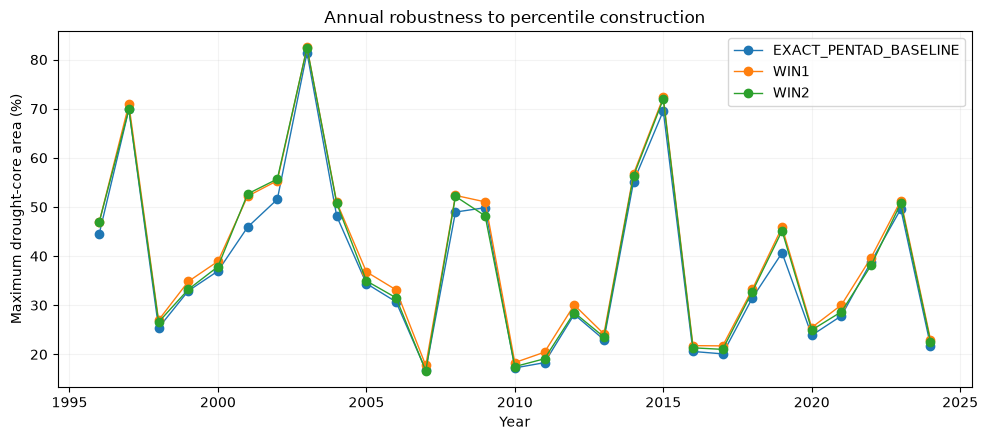

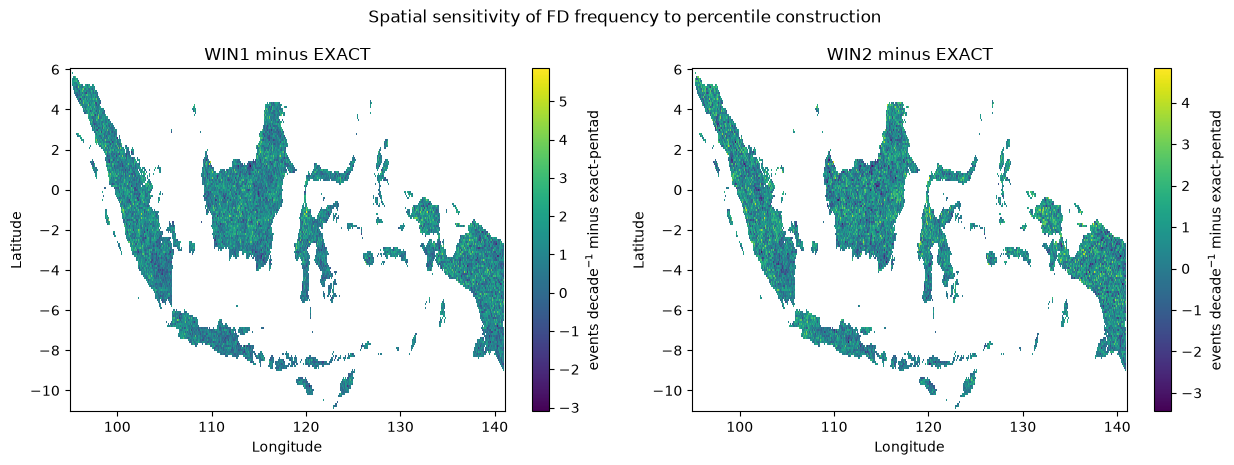

In [9]:
fig, ax = plt.subplots(
    figsize=(10, 4.5)
)

for name, group in annual.groupby(
    "method"
):
    ax.plot(
        group["year"],
        group[
            "maximum_drought_core_area_percent"
        ],
        marker="o",
        linewidth=1,
        label=name,
    )

ax.set(
    xlabel="Year",
    ylabel="Maximum drought-core area (%)",
    title=(
        "Annual robustness to "
        "percentile construction"
    ),
)

ax.legend()
ax.grid(alpha=0.15)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR
    / "figure_percentile_method_annual_core.png",
    dpi=FIG_DPI,
    bbox_inches="tight",
)
plt.show()


n_years = (
    ANALYSIS_END
    - ANALYSIS_START
    + 1
)

fig, axes = plt.subplots(
    1,
    len(WINDOWS_TO_BUILD),
    figsize=(
        6.3
        * len(WINDOWS_TO_BUILD),
        4.7,
    ),
    squeeze=False,
)

axes = axes.ravel()

for ax, half_window in zip(
    axes,
    WINDOWS_TO_BUILD,
):
    name = f"WIN{half_window}"

    diff = (
        (
            freq_maps[name]
            - freq_maps[
                "EXACT_PENTAD_BASELINE"
            ]
        )
        / n_years
        * 10.0
    )

    im = ax.pcolormesh(
        diff["longitude"],
        diff["latitude"],
        diff.where(valid),
        shading="auto",
    )

    fig.colorbar(
        im,
        ax=ax,
        label=(
            "events decade$^{-1}$ "
            "minus exact-pentad"
        ),
    )

    ax.set(
        xlabel="Longitude",
        ylabel="Latitude",
        title=(
            f"WIN{half_window} "
            "minus EXACT"
        ),
    )

fig.suptitle(
    "Spatial sensitivity of FD frequency "
    "to percentile construction"
)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR
    / "figure_percentile_method_frequency_difference.png",
    dpi=FIG_DPI,
    bbox_inches="tight",
)
plt.show()


## How to interpret this test

This is **not** a contest to decide which percentile map looks better.

The baseline is strengthened if WIN1/WIN2 retain:
- similar P20/P40 classification;
- high event-start and drought-core overlap;
- high spatial frequency correlation;
- stable Q90 hotspots;
- stable dominant years;
- similar event characteristics.

If absolute event frequency changes but these structural conclusions remain stable, report **frequency sensitivity plus structural robustness**.

If conclusions change substantially, percentile sampling uncertainty must be reported explicitly and investigated before making strong Indonesia-wide claims.


In [10]:
manifest = {
    "baseline": (
        "Exact calendar-pentad "
        "Gringorten percentile"
    ),
    "sensitivity": {
        "WIN1": (
            "target pentad ±1; "
            "up to 93 reference samples"
        ),
        "WIN2": (
            "target pentad ±2; "
            "up to 155 reference samples"
        ),
    },
    "purpose": (
        "Sensitivity to percentile "
        "reference-sample construction"
    ),
    "window_methods_are_standard": False,
    "detector_held_constant": {
        "P_start": 40,
        "P_drought": 20,
        "max_onset": 5,
        "min_decline_rate": 5,
        "persistence": 3,
        "recovery": 1,
    },
}

(
    OUTPUT_DIR
    / "manifest_03g_percentile_sensitivity.json"
).write_text(
    json.dumps(
        manifest,
        indent=2,
    ),
    encoding="utf-8",
)

for dsw in opened.values():
    dsw.close()

baseline.close()
rzsm_ds.close()
exact_ds.close()

print(
    "03g complete:",
    OUTPUT_DIR,
)


03g complete: D:\ERA5_LAND\output_fd_03g_percentile_sensitivity
